In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

In [3]:
import h5py
import jax.numpy as jnp

sample_idx = 10
bc_sample = 0.0 # From the paper: u(x) = 0 on the boundary

with h5py.File(FILE_PATH, 'r') as f:
    # 1. Print full dataset shapes to understand the tensor structure
    print("--- Full Dataset Shapes ---")
    print(f"nu shape:         {f['nu'].shape}")
    print(f"tensor shape:     {f['tensor'].shape}")
    print(f"x-coordinate:     {f['x-coordinate'].shape}")
    print(f"y-coordinate:     {f['y-coordinate'].shape}\n")
    
    # 2. Extract Coordinates directly from the dataset
    x_coords = jnp.array(f['x-coordinate'][:])
    y_coords = jnp.array(f['y-coordinate'][:])
    
    # 3. Extract Sample 0 
    a_sample = jnp.array(f['nu'][sample_idx])
    u_raw = jnp.array(f['tensor'][sample_idx])
    
    print(f"--- Sample {sample_idx} ---")
    print(f"Extracted 'a' (nu) shape: {a_sample.shape}")
    print(f"Extracted 'u_raw' (tensor) shape: {u_raw.shape}")

--- Full Dataset Shapes ---
nu shape:         (10000, 128, 128)
tensor shape:     (10000, 1, 128, 128)
x-coordinate:     (128,)
y-coordinate:     (128,)

--- Sample 10 ---
Extracted 'a' (nu) shape: (128, 128)
Extracted 'u_raw' (tensor) shape: (1, 128, 128)


E0715 15:29:20.713728   64013 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0715 15:29:20.724105   63902 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [4]:
import h5py
sample_idx = 0
bc_sample = 0.0 # From the paper: u(x) = 0 on the boundary

with h5py.File(FILE_PATH, 'r') as f:
    # Extract exact coordinates
    x_coords = np.array(f['x-coordinate'][:])
    y_coords = np.array(f['y-coordinate'][:])
    
    # Extract Sample 0
    a_sample = jnp.array(f['nu'][sample_idx])
    u_raw = jnp.array(f['tensor'][sample_idx])

# Squeeze out the extra dimension: (1, 128, 128) -> (128, 128)
u_sample = u_raw.squeeze()

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Solution 'u' Shape: {u_flat.shape}")
print(f"Boundary Condition 'bc': {bc_sample:.4f}")

Spatial Field 'a' Shape: (16384, 1)
Solution 'u' Shape: (16384, 1)
Boundary Condition 'bc': 0.0000


In [5]:
# Note: cell-centered grid rather than a node-centered grid
nx = len(x_coords) # 128
ny = len(y_coords) # 128
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Dynamically find the domain boundaries from the coordinates
x_l, x_u = float(np.min(x_coords)), float(np.max(x_coords)) # 0.00390625, 0.99609375
y_l, y_u = float(np.min(y_coords)), float(np.max(y_coords)) # 0.00390625, 0.99609375

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

print(f"Total grid points: {x.shape[0]}")
print(f"Boundary points extracted: {x_bc.shape[0]}")

Total grid points: 16384
Boundary points extracted: 508


In [6]:
epochs = 1000

# Setup the RFF Matrix
M = 256 # 2 * 256 = 512 RFF nodes
hidden_layers = [128, 128, 128, 128] # 4 * 128 = 512 MLP nodes
sigma = 0.4

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

class TrainableFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        u_pred = nn.Dense(1, use_bias=False)(combined_h)
            
        return u_pred

# Initialize
model = TrainableFeatureExtractor(hidden_layers=hidden_layers, B_matrix=B_matrix)
key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [7]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 2000 
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e}")

Pure Data-Loss Sanity Check:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Data MSE Loss: 1.3105e+01
Epoch 100 | Data MSE Loss: 1.1136e-02
Epoch 200 | Data MSE Loss: 3.5205e-03
Epoch 300 | Data MSE Loss: 1.7514e-03
Epoch 400 | Data MSE Loss: 1.2923e-03
Epoch 500 | Data MSE Loss: 8.0628e-04
Epoch 600 | Data MSE Loss: 5.5924e-04
Epoch 700 | Data MSE Loss: 5.0188e-04
Epoch 800 | Data MSE Loss: 5.4842e-04
Epoch 900 | Data MSE Loss: 2.6989e-04


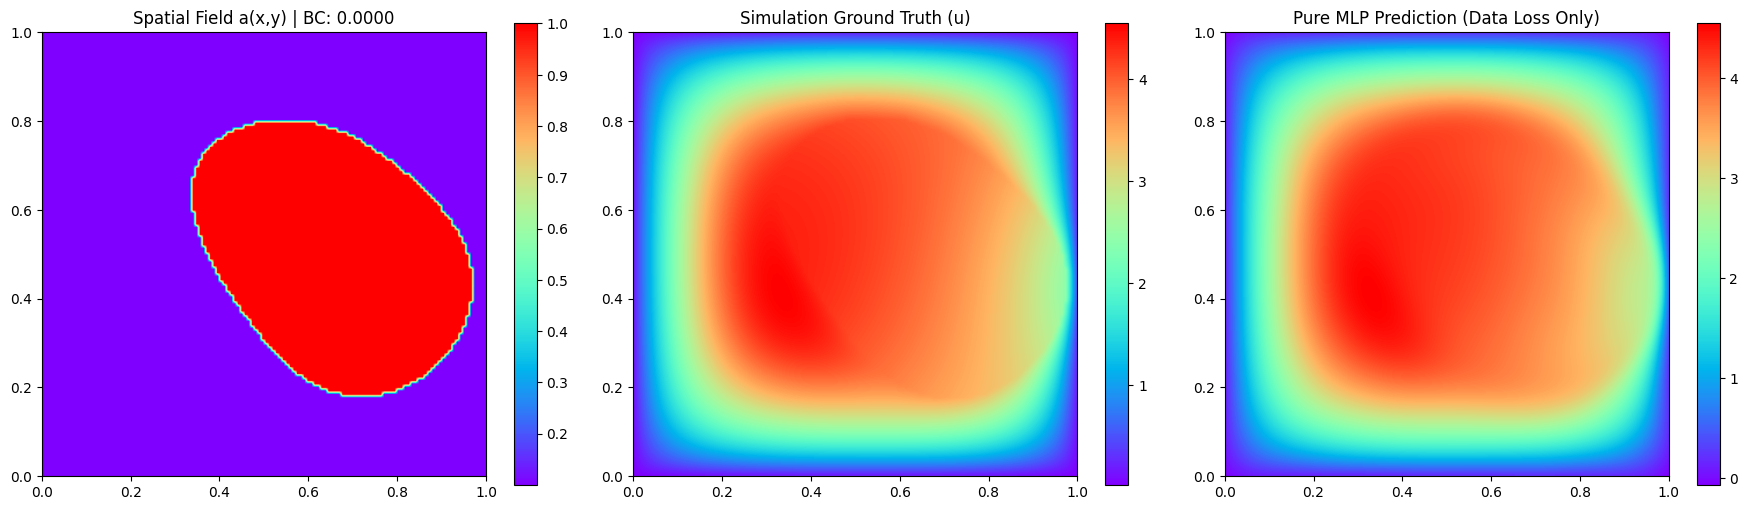

In [9]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [10]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

Weights successfully saved to pretrained_helmholtz_mlp.pkl
Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [11]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}

for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# DEFINE FROZEN MODEL (NO FINAL PREDICTION LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]
        
        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        
        return combined_h 

model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix=B_matrix)

In [19]:
beta = 10.0 # From dataset filename 2D_DarcyFlow_beta10.0_Train.hdf5

# Calculate spatial gradients of the field 'a' using central differences
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]
da_dx, da_dy = jnp.gradient(a_sample, h_x, h_y)

a_x_flat = da_dx.reshape(-1, 1)
a_y_flat = da_dy.reshape(-1, 1)

from scipy.ndimage import gaussian_filter

# 1. Smooth the discontinuous 'a' field
a_sample_np = np.array(a_sample)
a_sample_smoothed = jnp.array(gaussian_filter(a_sample_np, sigma=1))

# 2. Calculate spatial gradients on the SMOOTHED field
h_x = x_coords[1] - x_coords[0]
h_y = y_coords[1] - y_coords[0]
da_dx, da_dy = jnp.gradient(a_sample_smoothed, h_x, h_y)

# 3. Flatten for the network
a_flat_smooth = a_sample_smoothed.reshape(-1, 1)
a_x_flat = da_dx.reshape(-1, 1)
a_y_flat = da_dy.reshape(-1, 1)

# 4. Sample randomly from ALL points (Excluding spikes)
rng = jax.random.PRNGKey(42)

# Create a mask for regions where the gradient is flat
grad_magnitude = jnp.sqrt(a_x_flat**2 + a_y_flat**2)
flat_regions_mask = (grad_magnitude < 0.01).flatten() 

# Intersect interior points with flat regions
valid_indices = jnp.where(~bc_all & flat_regions_mask)[0]

spatial_batch_size = 10000 

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, valid_indices, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat_smooth[batch_idx]  # Use the smoothed 'a'
a_x_sampled = a_x_flat[batch_idx]
a_y_sampled = a_y_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val, a_x_val, a_y_val):
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # First derivatives (needed for Darcy)
    H_x = jax.jacfwd(get_H, argnums=0)(x_val, y_val)
    H_y = jax.jacfwd(get_H, argnums=1)(x_val, y_val)
    
    # Second derivatives
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
    
    H_x = jnp.squeeze(H_x)
    H_y = jnp.squeeze(H_y)
    H_xx = jnp.squeeze(H_xx)
    H_yy = jnp.squeeze(H_yy)
    
    # Darcy Flow PDE Operator: -(a_x * H_x + a_y * H_y + a * (H_xx + H_yy))
    L_H = -(a_x_val * H_x + a_y_val * H_y + a_val * (H_xx + H_yy))
    return L_H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    A_chunk = compute_A_pde_vmap(
        x_sampled[i:i + chunk_size], 
        y_sampled[i:i + chunk_size], 
        a_sampled[i:i + chunk_size],
        a_x_sampled[i:i + chunk_size],
        a_y_sampled[i:i + chunk_size]
    )
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.ones((spatial_batch_size, 1)) * beta

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

Compiling and evaluating PDE matrices for 10000 sampled points...
Compiling and evaluating BC matrices...
Finished building matrices! A_pde shape: (10000, 1024), A_bc shape: (508, 1024)


In [20]:
lambda_bcs = [1e3, 1e4, 1e6]
tik_regs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

all_sweep_preds = {}

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B)
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        all_sweep_preds[(lmbda, tik)] = u_pred_sweep
        
        # Track the best performing combination
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")


Starting Sweep:
--------------------------------------------------------------------------------
Lam: 1.0e+03 | Tik: 1.0e-01 | MSE: 8.32e-01 | PDE: 9.55e-03 | BC: 1.98e-05
Lam: 1.0e+03 | Tik: 1.0e-02 | MSE: 8.39e-01 | PDE: 8.93e-03 | BC: 1.40e-05
Lam: 1.0e+03 | Tik: 1.0e-03 | MSE: 8.39e-01 | PDE: 8.53e-03 | BC: 1.12e-05
Lam: 1.0e+03 | Tik: 1.0e-04 | MSE: 8.37e-01 | PDE: 8.32e-03 | BC: 1.01e-05
Lam: 1.0e+03 | Tik: 1.0e-05 | MSE: 8.34e-01 | PDE: 8.20e-03 | BC: 9.59e-06
Lam: 1.0e+03 | Tik: 1.0e-06 | MSE: 8.39e-01 | PDE: 7.99e-03 | BC: 8.72e-06
Lam: 1.0e+04 | Tik: 1.0e-01 | MSE: 8.11e-01 | PDE: 1.12e-02 | BC: 5.45e-06
Lam: 1.0e+04 | Tik: 1.0e-02 | MSE: 8.27e-01 | PDE: 1.02e-02 | BC: 3.86e-06
Lam: 1.0e+04 | Tik: 1.0e-03 | MSE: 8.30e-01 | PDE: 9.66e-03 | BC: 3.06e-06
Lam: 1.0e+04 | Tik: 1.0e-04 | MSE: 8.23e-01 | PDE: 9.42e-03 | BC: 2.70e-06
Lam: 1.0e+04 | Tik: 1.0e-05 | MSE: 8.19e-01 | PDE: 9.25e-03 | BC: 2.55e-06
Lam: 1.0e+04 | Tik: 1.0e-06 | MSE: 8.25e-01 | PDE: 8.91e-03 | BC: 2.47e-06
La

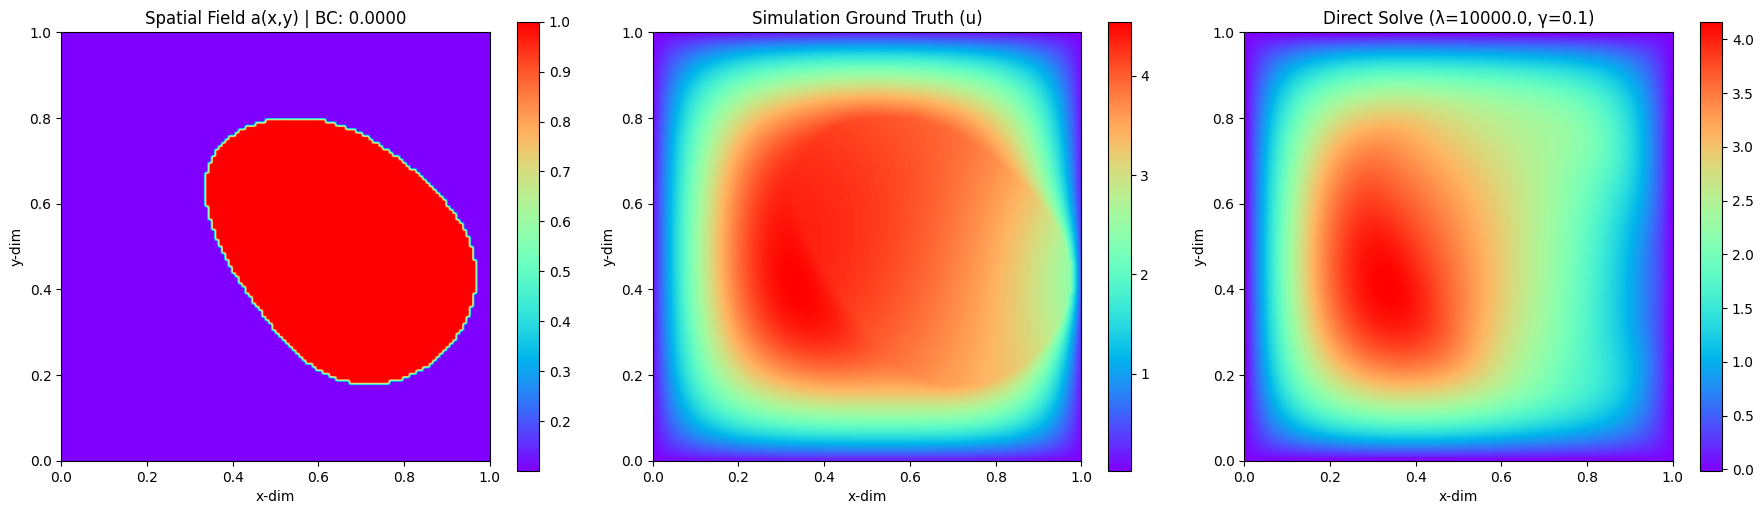

In [21]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
target_lambda = best_params_combo['lambda']
target_tik = best_params_combo['tik_reg']
target_u_pred = all_sweep_preds[(target_lambda, target_tik)]

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = target_u_pred.reshape(nx, ny).T
u_pred_plot = best_u_pred.reshape(nx,  ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]
 
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={target_lambda}, γ={target_tik})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [22]:
import jax.numpy as jnp

# 1. Extract the final layer weights the MLP learned during pure data training
w_learned = params['params']['Dense_4']['kernel']

# 2. Check the scale of our PDE matrix
mean_A = jnp.mean(jnp.abs(A_pde))
max_A = jnp.max(jnp.abs(A_pde))

# 3. Calculate the PDE loss using the network's OWN learned weights
pde_eval = A_pde @ w_learned
pde_residual = pde_eval - b_pde
mse_pde_learned = jnp.mean(pde_residual ** 2)

print("--- THE DERIVATIVE EXPLOSION CHECK ---")
print(f"Mean absolute value in A_pde: {mean_A:.4f}")
print(f"Max absolute value in A_pde:  {max_A:.4f}")
print("-" * 40)
print(f"PDE Loss using the network's OWN learned weights: {mse_pde_learned:.4e}")

--- THE DERIVATIVE EXPLOSION CHECK ---
Mean absolute value in A_pde: 4.2023
Max absolute value in A_pde:  476.2131
----------------------------------------
PDE Loss using the network's OWN learned weights: 1.0286e+02
